<a href="https://colab.research.google.com/github/RonakkudalAI/Practical-Machine-Learning/blob/main/Decision_Tree_Implementation(Day_9).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("/content/SNP.csv")
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [11]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [12]:
df.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [15]:
df.duplicated().sum()

np.int64(33)

In [16]:
df.shape

(400, 3)

In [19]:
df.drop_duplicates(inplace = True)

In [20]:
df.duplicated().sum()

np.int64(0)

<Axes: >

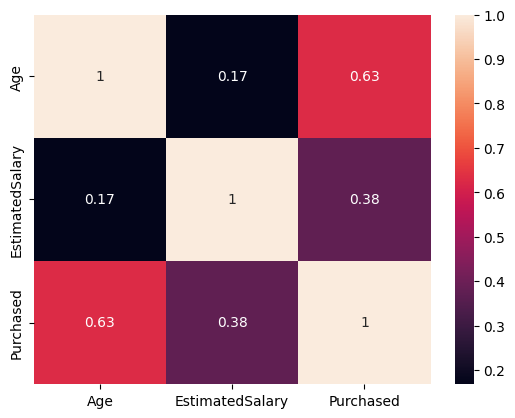

In [21]:
sns.heatmap(df.corr(),annot=True)

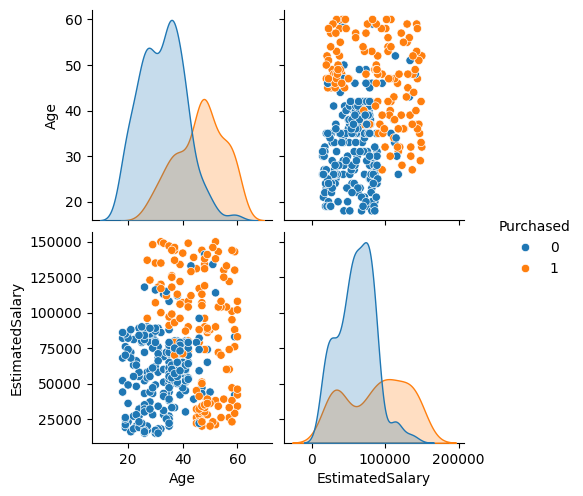

In [22]:
sns.pairplot(df,hue='Purchased')

<Axes: xlabel='Purchased', ylabel='Count'>

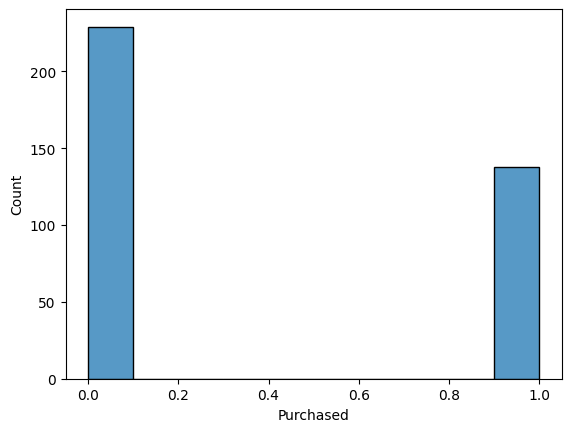

In [29]:
sns.histplot(x='Purchased',data = df)

<Axes: xlabel='Age', ylabel='count'>

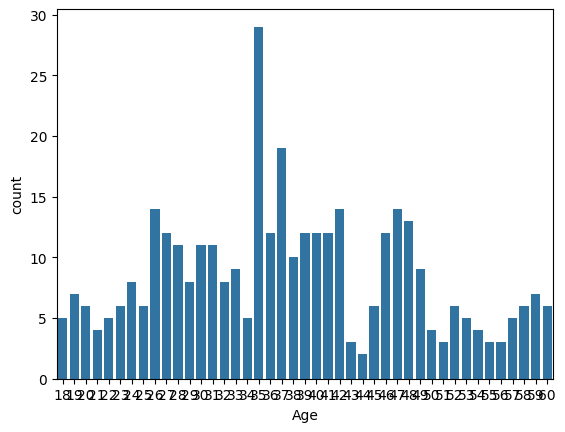

In [31]:
sns.countplot(x='Age',data=df)

In [24]:
df["Age_Sal_Ratio"] = df['Age']/df['EstimatedSalary']

In [25]:
df

,Age,EstimatedSalary,Purchased,Age_Sal_Ratio
0,19,19000,0,0.001000
1,35,20000,0,0.001750
2,26,43000,0,0.000605
3,27,57000,0,0.000474
4,19,76000,0,0.000250
...,...,...,...,...
395,46,41000,1,0.001122
396,51,23000,1,0.002217
397,50,20000,1,0.002500
398,36,33000,0,0.001091


In [26]:
X = df[['Age','EstimatedSalary','Age_Sal_Ratio']]
y = df['Purchased']

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,train_size=0.8, random_state=42)

In [49]:


from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)   # ✔️ correct
X_test_scaled = sc.transform(X_test)         # ✔️ correct

In [56]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()

# Train the model
model_lr.fit(X_train_scaled, y_train)
y_pred = model_lr.predict(X_test_scaled)



In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8918918918918919
Precision: 0.8571428571428571
Recall: 0.8571428571428571
F1 Score: 0.8571428571428571
Confusion Matrix:
 [[42  4]
 [ 4 24]]


In [59]:
from sklearn.tree import DecisionTreeClassifier

model_Dr =  DecisionTreeClassifier(criterion='entropy',max_depth=5,random_state = 42)

# Train the model
model_Dr.fit(X_train_scaled, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [60]:
y_pred_dt = model_Dr.predict(X_test_scaled)


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Accuracy: 0.8243243243243243
Precision: 0.7777777777777778
Recall: 0.75
F1 Score: 0.7636363636363637
Confusion Matrix:
 [[40  6]
 [ 7 21]]


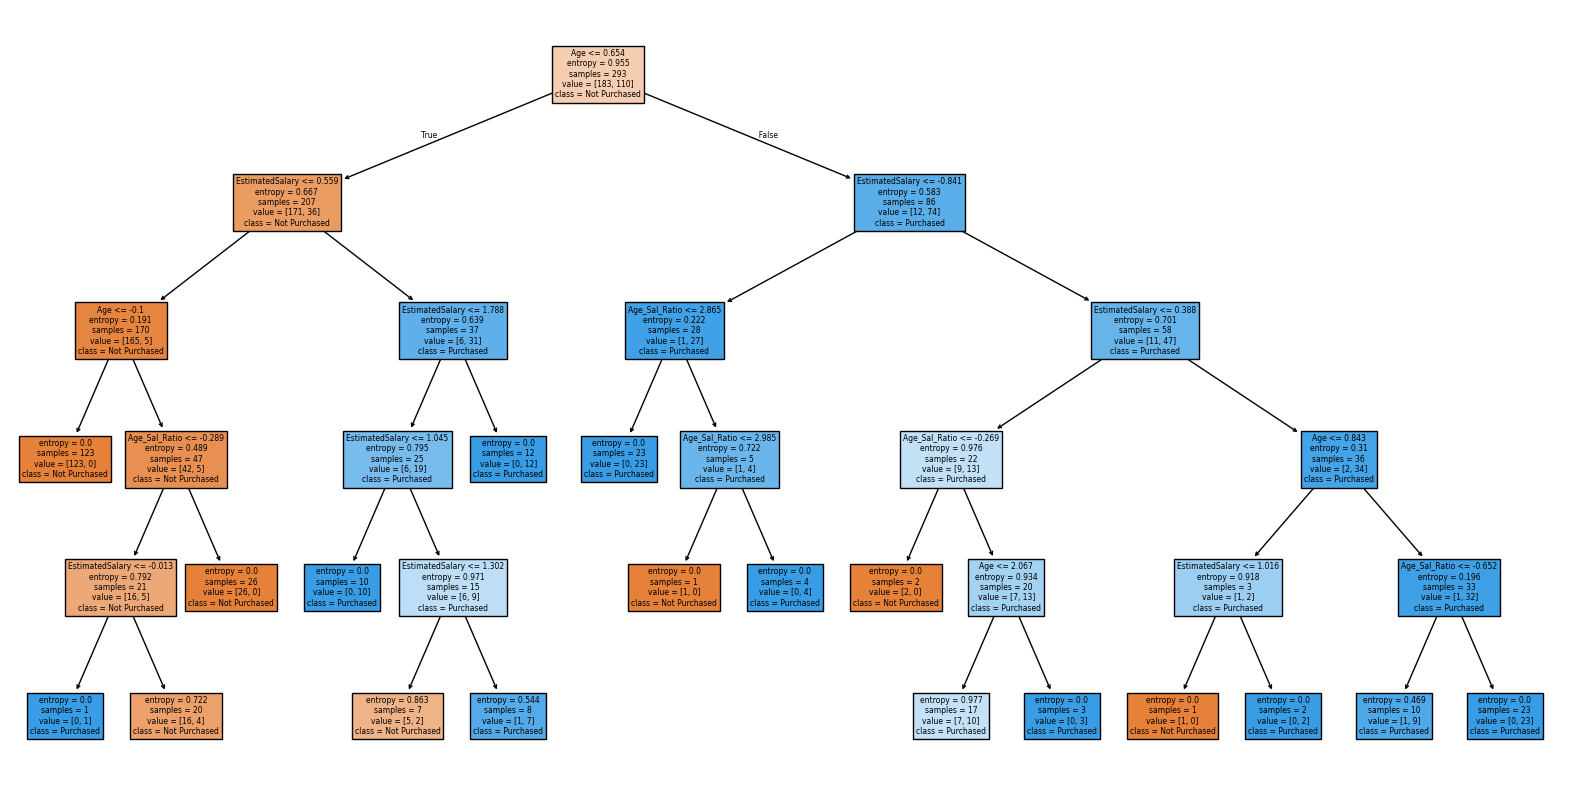

In [69]:
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    model_Dr,
    feature_names=['Age','EstimatedSalary','Age_Sal_Ratio'],
    class_names=["Not Purchased","Purchased"],
    filled=True
)

plt.show()